In [3]:
import pandas as pd
import warnings 
import json
import os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('_dataset.csv')

In [5]:
df.head()

,Mileage,Engine,Kerb Weight,Fuel,Transmission Type,Power,No. of Cylinders,Registration Year
0,15.1 kmpl,1984 cc,1579 kg,Petrol,Automatic,187.74 bhp,4.0,Jan 2021
1,16.8 kmpl,1353 cc,1485 kg,Petrol,Manual,113.43 bhp,4.0,Jan 2021
2,20.58 kmpl,1462 cc,1185 - 1210 kg,Petrol,Automatic,101.64 bhp,4.0,Dec 2022
3,21.11 kmpl,1462 cc,1140-1185 kg,NaN,Manual,101.64 bhp,4.0,May 2023
4,16.3 kmpl,1956 cc,NaN,Diesel,Manual,167.62 bhp,4.0,2023


In [6]:
df.shape

(5927, 8)

In [7]:
# Missing percentage count
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100
    print(f"{col}: {missing_percentage:.2f}% missing")

Mileage: 13.89% missing
Engine: 1.00% missing
Kerb Weight: 8.93% missing
Fuel: 13.60% missing
Transmission Type: 0.08% missing
Power: 2.38% missing
No. of Cylinders: 0.78% missing
Registration Year: 0.10% missing


In [8]:
def handle_missing_values(df, col):
    missing_pct = df[col].isnull().mean() * 100
    print(f"{col}: {missing_pct:.2f}% missing", end=" → ")

    # Drop if more than 50% missing
    if missing_pct > 50:
        df.drop(columns=[col], inplace=True)
        print("❌ Dropped (>50% missing)")

    # Between 30% and 50% — drop rows
    elif missing_pct > 30:
        df.dropna(subset=[col], inplace=True)
        print("🗑️ Dropped rows (30-50% missing)")

    # Between 10% and 30% — fill with mean/mode + add indicator column
    elif missing_pct > 10:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            strategy = f"mode ({fill_val})"
        else:
            fill_val = df[col].mean()
            strategy = f"mean ({fill_val:.2f})"

        df[f'{col}_was_missing'] = df[col].isnull().astype(int)  # indicator column
        df[col].fillna(fill_val, inplace=True)
        print(f"⚠️ Filled with {strategy} + added indicator column (10-30% missing)")

    # Less than 10% — fill with median/mode
    elif missing_pct > 0:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            strategy = f"mode ({fill_val})"
        else:
            fill_val = df[col].median()
            strategy = f"median ({fill_val:.2f})"

        df[col].fillna(fill_val, inplace=True)
        print(f"✅ Filled with {strategy} (<10% missing)")

    else:
        print("✅ No missing values")

    return df


# Apply to all columns
cols_with_missing = ['Mileage', 'Engine', 'Kerb Weight', 'Fuel',
                     'Transmission Type', 'Power', 'No. of Cylinders', 'Registration Year']

for col in cols_with_missing:
    df = handle_missing_values(df, col)

Mileage: 13.89% missing → ⚠️ Filled with mode (18.9 kmpl) + added indicator column (10-30% missing)
Engine: 1.00% missing → ✅ Filled with mode (1197 cc) (<10% missing)
Kerb Weight: 8.93% missing → ✅ Filled with mode (1100 kg) (<10% missing)
Fuel: 13.60% missing → ⚠️ Filled with mode (Petrol) + added indicator column (10-30% missing)
Transmission Type: 0.08% missing → ✅ Filled with mode (Manual) (<10% missing)
Power: 2.38% missing → ✅ Filled with mode (81.86 bhp) (<10% missing)
No. of Cylinders: 0.78% missing → ✅ Filled with median (4.00) (<10% missing)
Registration Year: 0.10% missing → ✅ Filled with mode (2023) (<10% missing)


In [9]:
df['Fuel'].value_counts()

Fuel
Petrol    4617
Diesel    1196
CNG        114
Name: count, dtype: int64

1. Mileage

In [10]:
df['Mileage'] = df['Mileage'].str.extract(r'(\d+\.?\d*)').astype(float)

2. Engine

In [11]:
df['Engine'] = df['Engine'].str.extract(r'(\d+)').astype(float)

3. Weight

In [12]:
df['Kerb Weight'] = df['Kerb Weight'].str.extract(r'(\d+)').astype(float)

4. Power

In [13]:
df['Power'] = df['Power'].str.extract(r'(\d+\.?\d*)').astype(float)

5. Registration Year

In [14]:
df['Registration Year'] = pd.to_numeric(
    df['Registration Year'].str.extract(r'(\d{4})')[0],
    errors='coerce'
)

6. Transmission Type

In [15]:
df['Transmission Type'] = df['Transmission Type'].map({
                                'Automatic': 1,
                                'Manual': 0
                            })

7. Fuel

In [16]:
def encode_and_show_dropped(df, column, drop_first=True):
    dummies = pd.get_dummies(df[column], prefix=column, drop_first=drop_first)
    
    all_categories = df[column].unique()
    encoded_categories = [col.replace(f"{column}_", "") for col in dummies.columns]
    dropped_categories = [cat for cat in all_categories if cat not in encoded_categories]
    
    print(f"All categories:     {list(all_categories)}")
    print(f"Encoded categories: {encoded_categories}")
    print(f"Dropped categories: {dropped_categories}")
    
    return dummies

# usage
fuel_dummies = encode_and_show_dropped(df, 'Fuel', drop_first=True)
df = pd.concat([df.drop(columns=['Fuel']), fuel_dummies], axis=1)


All categories:     ['Petrol', 'Diesel', 'CNG']
Encoded categories: ['Diesel', 'Petrol']
Dropped categories: ['CNG']


In [17]:
df['Mileage'].fillna(df['Mileage'].median(), inplace=True)

In [18]:
df.shape

(5927, 11)

---

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

In [20]:
# Features and target
X = df.drop(columns=['Mileage'])
y = df['Mileage']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
total = len(X_train)

batch_sizes = sorted(set([
    int(total * 0.10),
    int(total * 0.20),
    int(total * 0.30),
    int(total * 0.40),
    int(total * 0.50),
    int(total * 0.60),
    int(total * 0.70),
    int(total * 0.80),
    int(total * 0.90),
    total
]))

train_scores, val_scores, actual_sizes = [], [], []

for size in batch_sizes:
    size = min(size, len(X_train))   

    X_batch = X_train.iloc[:size]
    y_batch = y_train.iloc[:size]

    model = XGBRegressor(
        n_estimators=200,
        max_depth=6,            
        min_child_weight=2,    
        subsample=0.85,      
        colsample_bytree=0.85,  
        learning_rate=0.05,   
        reg_alpha=0.05,        
        reg_lambda=0.8,         
        random_state=42,
        verbosity=0
    )
    model.fit(X_batch, y_batch)

    train_r2 = r2_score(y_batch, model.predict(X_batch))
    val_r2   = r2_score(y_test,  model.predict(X_test))

    train_scores.append(round(train_r2, 4))
    val_scores.append(round(val_r2, 4))
    actual_sizes.append(size)

    print(f"Rows: {size:>5} | Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")
 

Rows:   474 | Train R²: 0.9864 | Val R²: 0.7857
Rows:   948 | Train R²: 0.9757 | Val R²: 0.8263
Rows:  1422 | Train R²: 0.9690 | Val R²: 0.8465
Rows:  1896 | Train R²: 0.9637 | Val R²: 0.8625
Rows:  2370 | Train R²: 0.9640 | Val R²: 0.8708
Rows:  2844 | Train R²: 0.9601 | Val R²: 0.8794
Rows:  3318 | Train R²: 0.9567 | Val R²: 0.8840
Rows:  3792 | Train R²: 0.9536 | Val R²: 0.8931
Rows:  4266 | Train R²: 0.9543 | Val R²: 0.8997
Rows:  4741 | Train R²: 0.9533 | Val R²: 0.8967


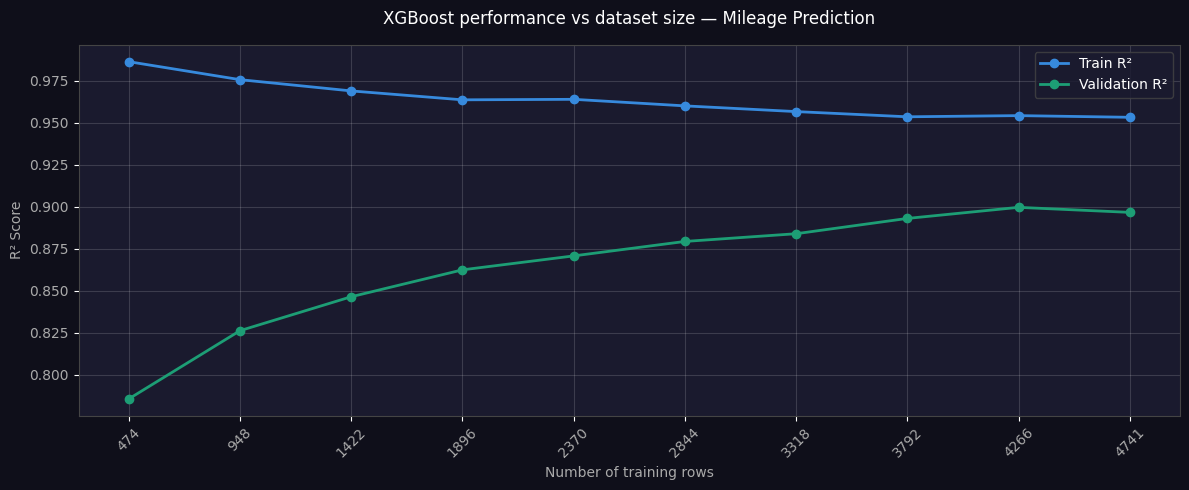

In [22]:
plt.style.use('dark_background')

plt.figure(figsize=(12, 5))
plt.plot(actual_sizes, train_scores, label='Train R²', marker='o', color='#378ADD', linewidth=2)
plt.plot(actual_sizes, val_scores,   label='Validation R²', marker='o', color='#1D9E75', linewidth=2)

plt.xlabel("Number of training rows", color='#aaaaaa')
plt.ylabel("R² Score", color='#aaaaaa')
plt.title("XGBoost performance vs dataset size — Mileage Prediction", color='white', pad=15)

plt.xticks(actual_sizes, rotation=45, color='#aaaaaa')
plt.yticks(color='#aaaaaa')

plt.gca().set_facecolor('#1a1a2e')
plt.gcf().set_facecolor('#0f0f1a')

plt.gca().spines['bottom'].set_color('#444444')
plt.gca().spines['left'].set_color('#444444')
plt.gca().spines['top'].set_color('#444444')
plt.gca().spines['right'].set_color('#444444')

plt.legend(facecolor='#1a1a2e', edgecolor='#444444', labelcolor='white')
plt.grid(True, alpha=0.15, color='#ffffff')
plt.tight_layout()
plt.show()

In [23]:
# import os
# import joblib
# os.makedirs("model", exist_ok=True)
# joblib.dump(best_model, "model/mileage_model.pkl")
# print("Model saved!")
